<a href="https://colab.research.google.com/github/alfanfhd/Pembelajaran-Mesin-2026/blob/main/TG4_254107023007_alfan_fahat_m.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 1

In [12]:
# Persiapan data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Membaca dataset
df = pd.read_csv('Iris.csv')

# Seleksi Fitur
X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

# --- BAGIAN UNTUK MENAMPILKAN KEDUANYA ---
print("1. Tampilan Data Lengkap (df):")
display(df.head())

print("\n2. Tampilan Data Fitur Setelah Dipotong (X):")
display(X.head())

1. Tampilan Data Lengkap (df):


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



2. Tampilan Data Fitur Setelah Dipotong (X):


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


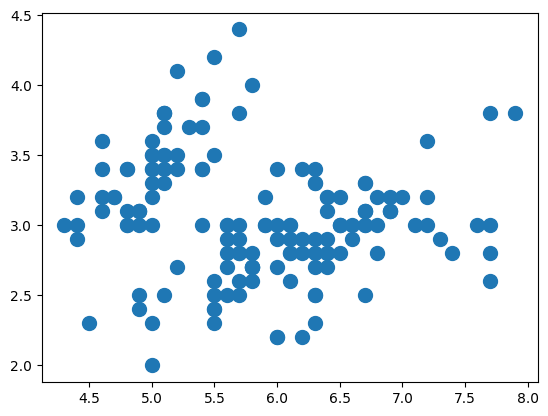

In [13]:
# Plot Data
# Karena data 4 dimensi, maka akan kita coba
# plot cluster berdasarkan Sepal Length dan Sepal Width  saja

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)

In [14]:
# Buat Model KMeans
# Kali ini kita coba menggunakan k=2 - anggap saja kita tidak tahu jumlah label ada 3 :)

from sklearn.cluster import KMeans

# Inisiasi obyek KMeans
cl_kmeans = KMeans(n_clusters=2)

# Fit dan predict model
y_kmeans = cl_kmeans.fit_predict(X)

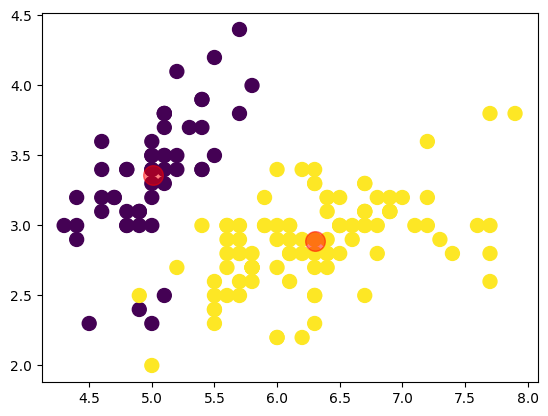

In [15]:
# Plot hasi cluster berdasarkan Sepal Length dan Sepal Width
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans)

# Plot centroid
centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

In [16]:
# Cek Nilai SSE
print(f'Nilai SSE: {cl_kmeans.inertia_}')

Nilai SSE: 152.36870647733915


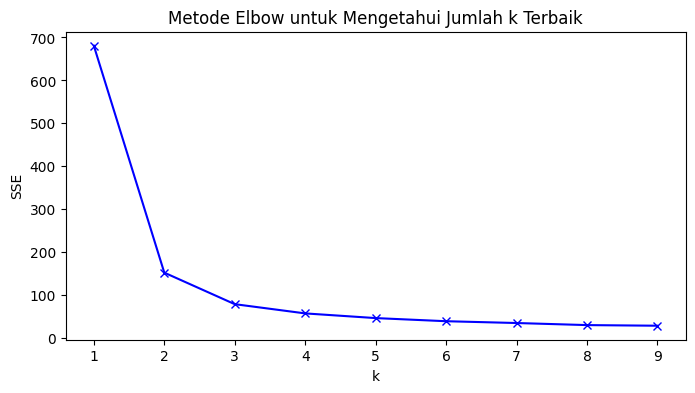

In [19]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1, 10)

# Cek nilai SSE setiap k
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42) # Tambahkan random_state agar konsisten
    kmeanModel.fit(X)
    sse.append(kmeanModel.inertia_)

# Plotting the distortions
plt.figure(figsize=(8, 4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [20]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=680.8243999999996
k=2; SSE=152.36870647733915
k=3; SSE=78.94506582597728
k=4; SSE=57.44028021295475
k=5; SSE=46.535582051282034
k=6; SSE=39.251830892636775
k=7; SSE=35.04275995246584
k=8; SSE=30.217021122152712
k=9; SSE=28.7564561965812


# Praktikum 2

In [21]:
#import library
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

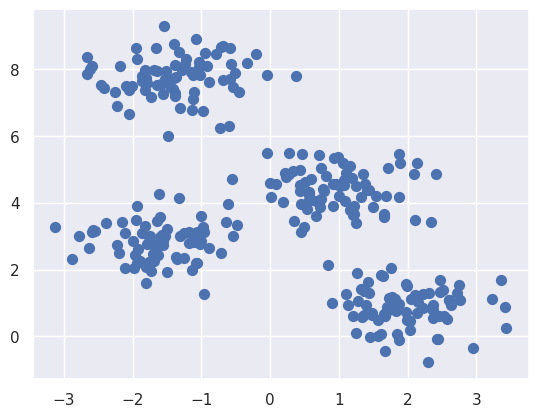

In [22]:
#Pengantar k-Means
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

In [23]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

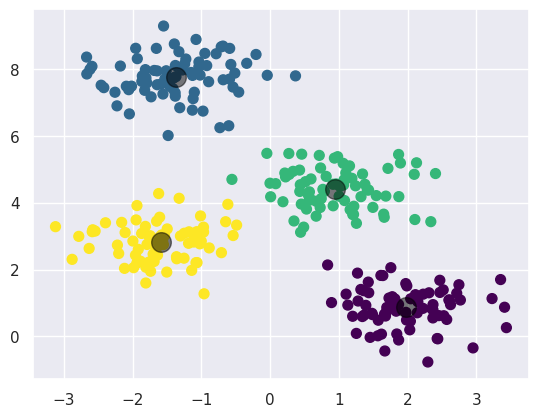

In [24]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5)

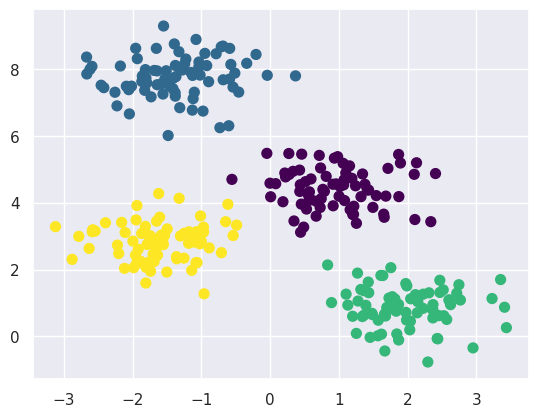

In [25]:
#Algoritma Expectation-Maximization
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=2):
    # 1. Randomly choose clusters
    rng = np.random.RandomState(rseed)
    i = rng.permutation(X.shape[0])[:n_clusters]
    centers = X[i]

    while True:
        # 2a. input label center yang baru
        labels = pairwise_distances_argmin(X, centers)

        # 2b. update center dari titik baru
        new_centers = np.array([X[labels == i].mean(0)
                                for i in range(n_clusters)])

        # 2c. cek konvergensi
        if np.all(centers == new_centers):
            break
        centers = new_centers

    return centers, labels

centers, labels = find_clusters(X, 4)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

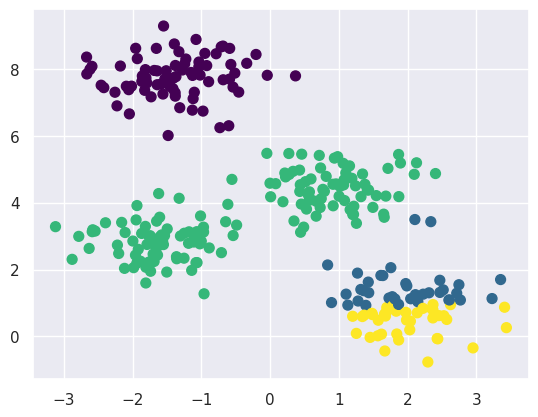

In [26]:
#Perubahan random
centers, labels = find_clusters(X, 4, rseed=0)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

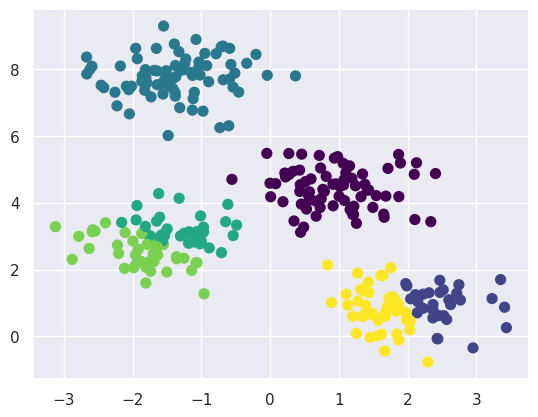

In [27]:
#Optimalisasi Jumlah Klaster
labels = KMeans(6, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [28]:
#Batas Klaster yang Tidak Selalu Linier
from sklearn.datasets import make_moons
X, y = make_moons(200, noise=.05, random_state=0)

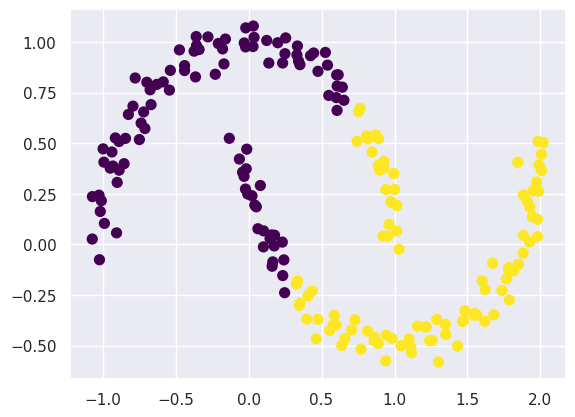

In [29]:
labels = KMeans(2, random_state=0).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels,s=50, cmap='viridis');

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


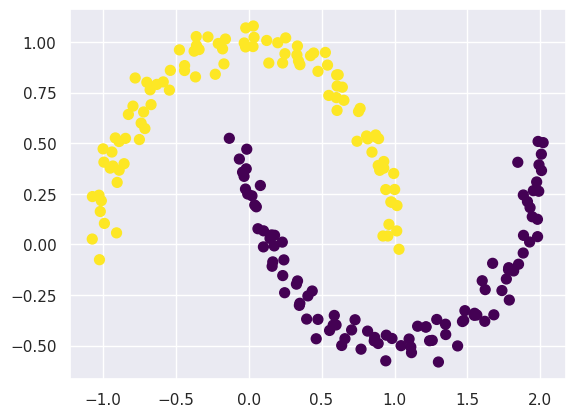

In [30]:
from sklearn.cluster import SpectralClustering
model = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                           assign_labels='kmeans')
labels = model.fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, s=50, cmap='viridis');

In [31]:
#Contoh Kasus 1: Karakter Angka
from sklearn.datasets import load_digits
digits = load_digits()
digits.data.shape

(1797, 64)

In [32]:
# terapkan K-Means
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits.data)
kmeans.cluster_centers_.shape

(10, 64)

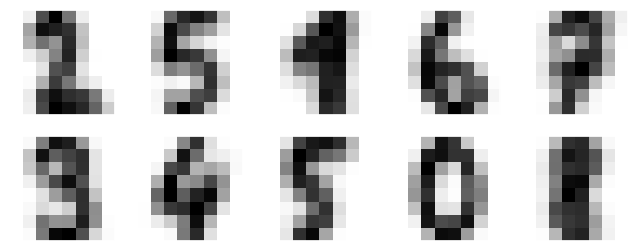

In [33]:
fig, ax = plt.subplots(2, 5, figsize=(8, 3))
centers = kmeans.cluster_centers_.reshape(10, 8, 8)
for axi, center in zip(ax.flat, centers):
    axi.set(xticks=[], yticks=[])
    axi.imshow(center, interpolation='nearest', cmap=plt.cm.binary)

In [34]:
from scipy.stats import mode

labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

In [35]:
from sklearn.metrics import accuracy_score
accuracy_score(digits.target, labels)

0.7440178074568725

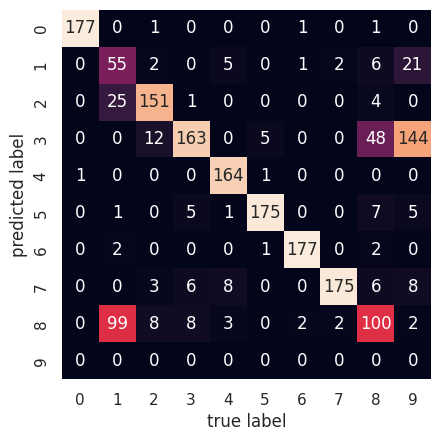

In [36]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(digits.target, labels)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel('true label')
plt.ylabel('predicted label');

In [37]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, init='random', random_state=0)
digits_proj = tsne.fit_transform(digits.data)

# hitung klaster
kmeans = KMeans(n_clusters=10, random_state=0)
clusters = kmeans.fit_predict(digits_proj)

# permutasi label
labels = np.zeros_like(clusters)
for i in range(10):
    mask = (clusters == i)
    labels[mask] = mode(digits.target[mask])[0]

# hitung akurasi
accuracy_score(digits.target, labels)

0.9410127991096272

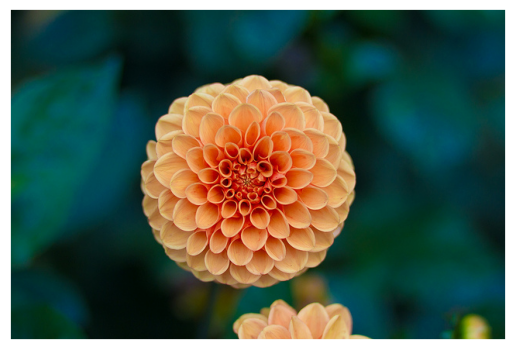

In [38]:
#Studi Kasus 2: Kompresi Citra
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [39]:
flower.shape

(427, 640, 3)

In [40]:
data = flower / 255.0
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [41]:
def plot_pixels(data, title, colors=None, N=10000):
    if colors is None:
        colors = data

    # choose a random subset
    rng = np.random.RandomState(0)
    i = rng.permutation(data.shape[0])[:N]
    colors = colors[i]
    R, G, B = data[i].T

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    ax[0].scatter(R, G, color=colors, marker='.')
    ax[0].set(xlabel='Red', ylabel='Green', xlim=(0, 1), ylim=(0, 1))

    ax[1].scatter(R, B, color=colors, marker='.')
    ax[1].set(xlabel='Red', ylabel='Blue', xlim=(0, 1), ylim=(0, 1))

    fig.suptitle(title, size=20);

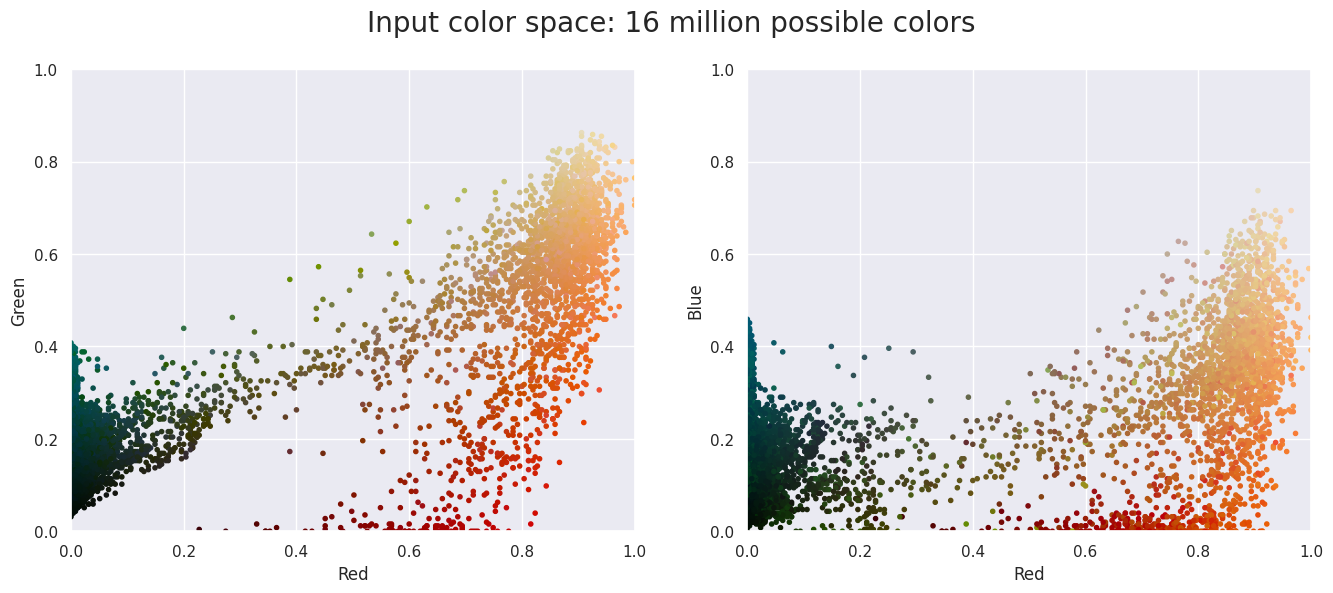

In [42]:
plot_pixels(data, title='Input color space: 16 million possible colors')

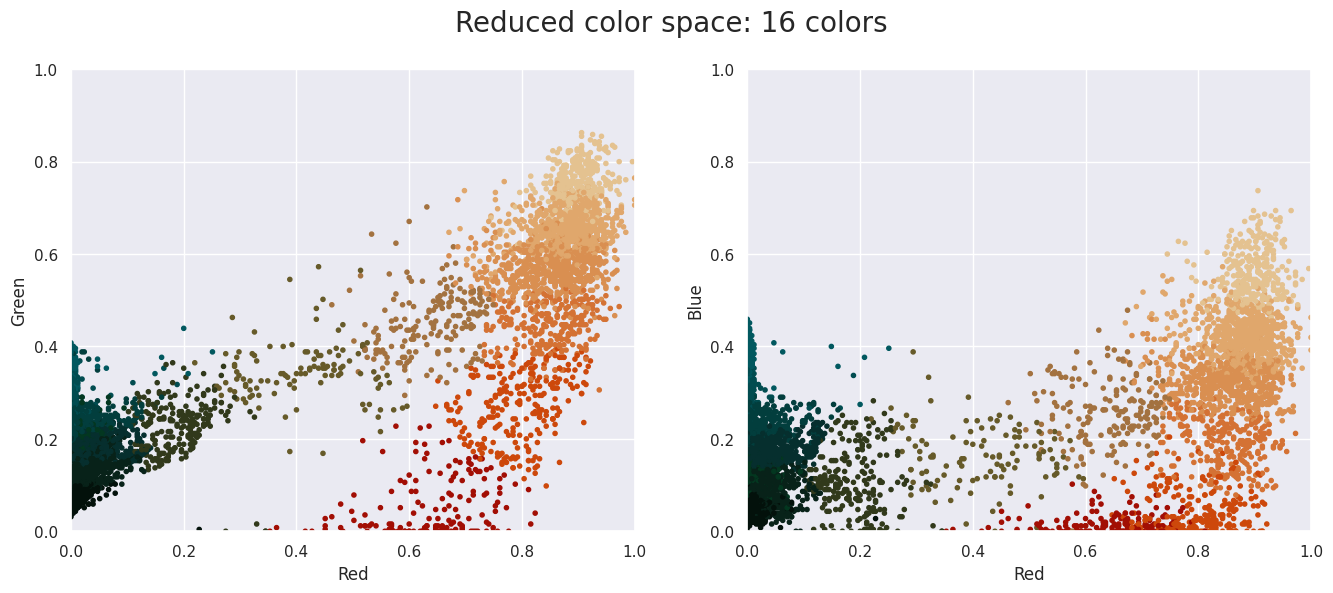

In [43]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]

plot_pixels(data, colors=new_colors,title="Reduced color space: 16 colors")

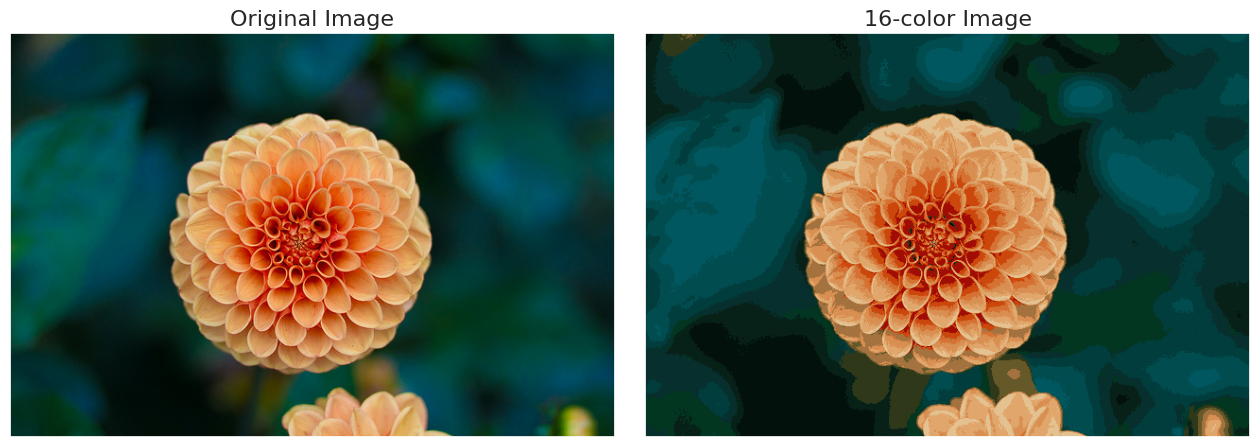

In [44]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

# Praktikum 3

Pembuatan Dataset Sintetis
Untuk mempelajari DBSCAN, kita akan membuat dataset sederhana berupa 3 klaster buatan menggunakan fungsi  make_blobs  dari Scikit-Learn.

In [49]:
# Bagian yang kosong diisi dengan nama fungsinya
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

# Bagian () kosong diisi dengan StandardScaler()
X = StandardScaler().fit_transform(X)

print("Data berhasil dibuat!")
print("Bentuk X:", X.shape)

Data berhasil dibuat!
Bentuk X: (750, 2)


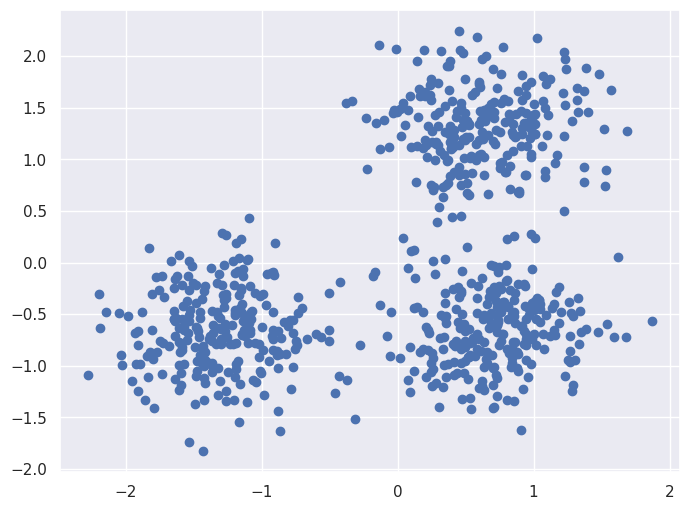

In [54]:
import matplotlib.pyplot as plt

# Membuat figure dengan ukuran yang proporsional
plt.figure(figsize=(8, 6))

# Membuat scatter plot (hanya ini yang diperlukan)
plt.scatter(X[:, 0], X[:, 1])

# Menampilkan grafik
plt.show()

In [56]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN  # <--- Ini yang kosong di modul, kita isi 'DBSCAN'

# Inisialisasi dan latih model DBSCAN
# db = (eps=..., min_samples=...) -> ini salah, harus db = DBSCAN(...)
db = DBSCAN(eps=0.3, min_samples=10).fit(X)

# Mengambil label hasil clustering
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
# Menghitung jumlah cluster (mengabaikan label -1 yang berarti noise)
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
# Menghitung jumlah titik noise (label -1)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


In [57]:
# Evaluasi Kualitas Klasterisasi
# Karena kita menggunakan dataset sintetis (make_blobs), kita tahu label aslinya (labels_true).
# Ini memungkinkan kita mengukur kualitas DBSCAN dengan berbagai metrik evaluasi.

# Import fungsi metrik yang dibutuhkan
from sklearn import metrics

# Menghitung dan menampilkan setiap metrik
print(f"Homogeneity: {(metrics.homogeneity_score(labels_true, labels)):.3f}")
print(f"Completeness: {(metrics.completeness_score(labels_true, labels)):.3f}")
print(f"V-measure: {(metrics.v_measure_score(labels_true, labels)):.3f}")
print(f"Adjusted Rand Index: {(metrics.adjusted_rand_score(labels_true, labels)):.3f}")
print(
    "Adjusted Mutual Information: "
    f"{(metrics.adjusted_mutual_info_score(labels_true, labels)):.3f}"
)
print(f"Silhouette Coefficient: {(metrics.silhouette_score(X, labels)):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


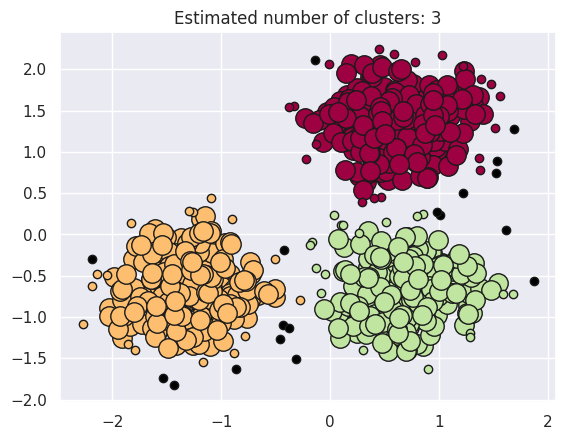

In [58]:
# Visualisasi Hasil Klasterisasi
# Kita akan memvisualisasikan hasil DBSCAN.
# Core sample ditampilkan dengan titik besar.
# Non-core sample ditampilkan dengan titik kecil.
# Noise ditampilkan dengan warna hitam.

import matplotlib.pyplot as plt
import numpy as np

unique_labels = set(labels)

# Membuat mask untuk core samples (memperbaiki kode yang kosong di modul)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

# Membuat daftar warna (memperbaiki kode yang kosong di modul)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    # Plot Core samples (titik besar)
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter( # <--- Fungsi plt.scatter hilang di modul
        xy[:, 0],
        xy[:, 1],
        c=[tuple(col)], # <--- Parameter warna disesuaikan
        marker="o",
        edgecolors="k",
        s=14 * 14, # <--- markersize=14 diubah ke skala area (s)
    )

    # Plot Non-core samples (titik kecil)
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter( # <--- Fungsi plt.scatter hilang di modul
        xy[:, 0],
        xy[:, 1],
        c=[tuple(col)], # <--- Parameter warna disesuaikan
        marker="o",
        edgecolors="k",
        s=6 * 6, # <--- markersize=6 diubah ke skala area (s)
    )

# Menampilkan judul dan grafik
plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

# Tugas Praktikum

In [59]:
# ==========================================
# Tugas K-Means - Nomor 1
# Gunakan data 'Mall_Customers.csv'
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Membaca dataset
df_mall = pd.read_csv('Mall_Customers.csv')

# Tampilkan 5 data teratas
print("Tampilan Data Awal:")
display(df_mall.head())

Tampilan Data Awal:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [60]:
# ==========================================
# Tugas K-Means - Nomor 2
# Tentukan fitur yang tepat untuk clustering (minimal 2)
# ==========================================

# Fitur yang dipilih: 'Annual Income (k$)' dan 'Spending Score (1-100)'
# Kolom indeks 3 = Annual Income, Kolom indeks 4 = Spending Score
X_mall = df_mall.iloc[:, [3, 4]].values

print("Fitur yang digunakan untuk clustering:")
print("1. Annual Income (k$)")
print("2. Spending Score (1-100)")
print("\nBentuk data X:", X_mall.shape)

Fitur yang digunakan untuk clustering:
1. Annual Income (k$)
2. Spending Score (1-100)

Bentuk data X: (200, 2)


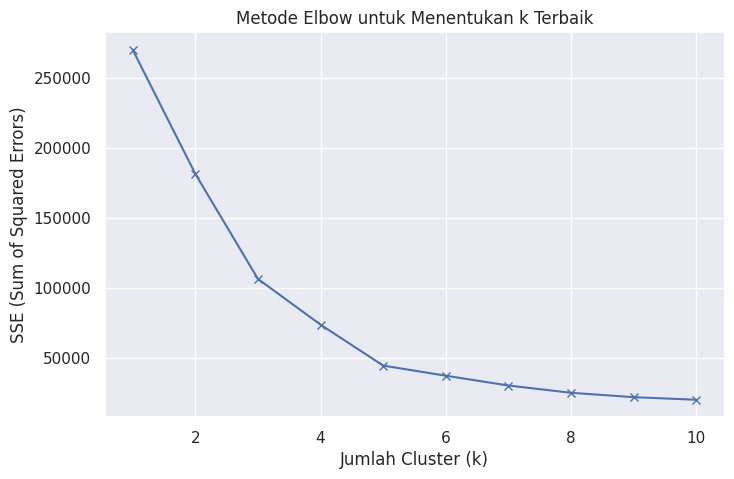

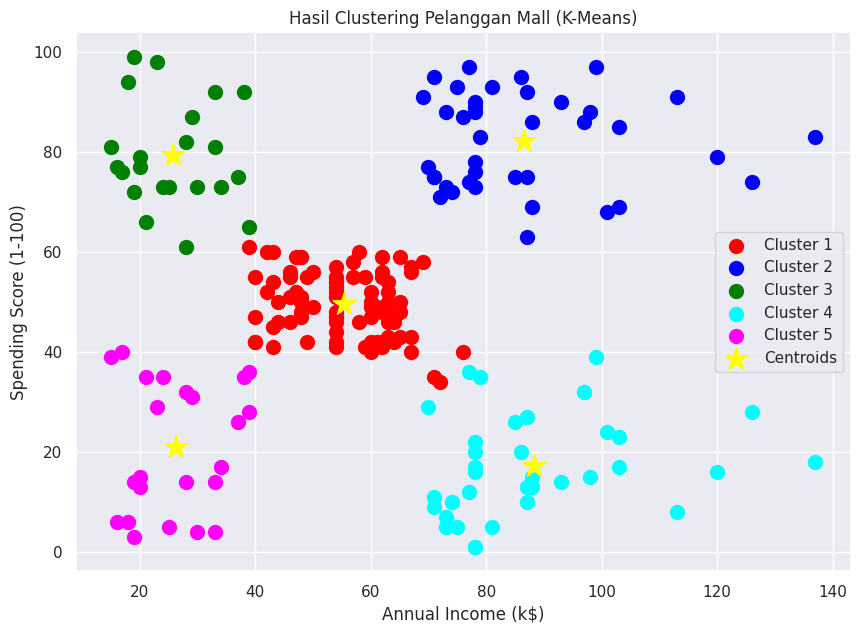

In [61]:
# ==========================================
# Tugas K-Means - Nomor 3
# Buat model K-Means dengan mempertimbangkan jumlah k terbaik
# ==========================================

# Langkah 3a: Metode Elbow untuk mencari k terbaik
sse = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_mall)
    sse.append(kmeans.inertia_)

# Visualisasi Metode Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, sse, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('SSE (Sum of Squared Errors)')
plt.title('Metode Elbow untuk Menentukan k Terbaik')
plt.grid(True)
plt.show()

# Langkah 3b: Buat model K-Means dengan k terbaik (misal k=5 dari grafik elbow)
k_terbaik = 5
kmeans_final = KMeans(n_clusters=k_terbaik, random_state=42, n_init=10)
y_kmeans = kmeans_final.fit_predict(X_mall)

# Visualisasi Hasil Clustering
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(k_terbaik):
    plt.scatter(X_mall[y_kmeans == i, 0], X_mall[y_kmeans == i, 1],
                s=100, c=colors[i], label=f'Cluster {i+1}')

# Plot centroids
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids', marker='*')

plt.title('Hasil Clustering Pelanggan Mall (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)
plt.show()

In [62]:
# ==========================================
# Tugas DBSCAN - Nomor 1
# Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

# Membuat dataset make_moons
X_moons, labels_true_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)

# Normalisasi data menggunakan StandardScaler
X_moons = StandardScaler().fit_transform(X_moons)

print("Dataset make_moons berhasil dibuat.")
print("Bentuk data X:", X_moons.shape)

Dataset make_moons berhasil dibuat.
Bentuk data X: (1000, 2)


In [63]:
# ==========================================
# Tugas DBSCAN - Nomor 2
# Jalankan DBSCAN (eps=0.2, min_samples=5), hitung jumlah klaster & noise
# ==========================================

# Menjalankan DBSCAN
db_moons = DBSCAN(eps=0.2, min_samples=5).fit(X_moons)
labels_moons = db_moons.labels_

# Hitung jumlah cluster (abaikan noise -1)
n_clusters_moons = len(set(labels_moons)) - (1 if -1 in labels_moons else 0)

# Hitung jumlah noise
n_noise_moons = list(labels_moons).count(-1)

print(f"Jumlah cluster: {n_clusters_moons}")
print(f"Jumlah noise: {n_noise_moons}")

Jumlah cluster: 2
Jumlah noise: 0


In [64]:
# ==========================================
# Tugas DBSCAN - Nomor 3
# Evaluasi dengan metrik: Homogeneity, Completeness, V-measure, ARI, AMI, Silhouette
# ==========================================

print("--- Metrik Evaluasi ---")
print(f"Homogeneity: {metrics.homogeneity_score(labels_true_moons, labels_moons):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true_moons, labels_moons):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true_moons, labels_moons):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true_moons, labels_moons):.3f}")
print(f"Adjusted Mutual Information: {metrics.adjusted_mutual_info_score(labels_true_moons, labels_moons):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X_moons, labels_moons):.3f}")

--- Metrik Evaluasi ---
Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.391


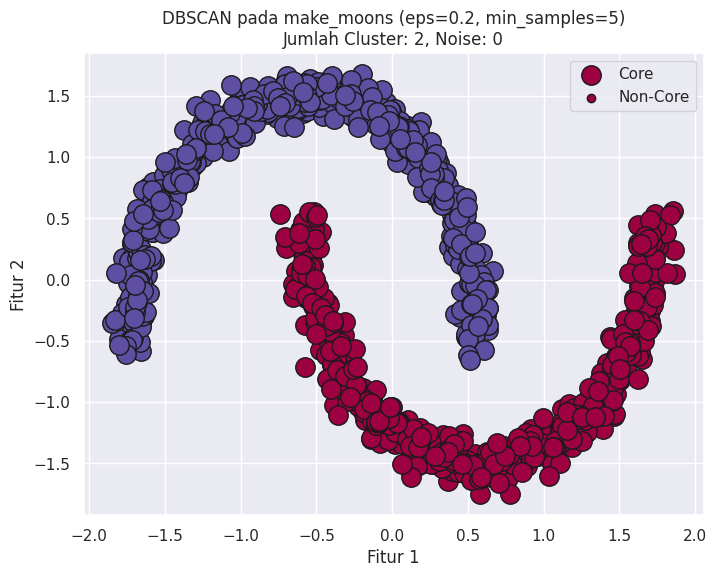

In [65]:
# ==========================================
# Tugas DBSCAN - Nomor 4
# Visualisasikan hasil DBSCAN
# Core sample = titik besar, non-core = titik kecil, noise = hitam
# ==========================================

unique_labels = set(labels_moons)

# Membuat mask untuk core samples
core_samples_mask = np.zeros_like(labels_moons, dtype=bool)
core_samples_mask[db_moons.core_sample_indices_] = True

# Membuat daftar warna
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

plt.figure(figsize=(8, 6))
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Hitam untuk noise

    class_member_mask = (labels_moons == k)

    # Plot core samples (titik besar)
    xy = X_moons[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[tuple(col)], marker='o',
                edgecolors='k', s=14*14, label='Core' if k == 0 else "")

    # Plot non-core samples (titik kecil)
    xy = X_moons[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[tuple(col)], marker='o',
                edgecolors='k', s=6*6, label='Non-Core' if k == 0 else "")

plt.title(f"DBSCAN pada make_moons (eps=0.2, min_samples=5)\n"
          f"Jumlah Cluster: {n_clusters_moons}, Noise: {n_noise_moons}")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.legend()
plt.show()

In [66]:
# ==========================================
# Tugas DBSCAN - Nomor 5
# Eksperimen: eps = 0.05, 0.1, 0.3, 0.5 dan min_samples = 3, 10, 20
# Catat perubahan klaster, noise, dan kualitas evaluasi (ARI)
# ==========================================

print("--- Eksperimen Parameter DBSCAN ---")
print(f"{'eps':<8}{'min_samples':<14}{'Cluster':<10}{'Noise':<10}{'ARI':<10}")
print("-" * 52)

eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

for eps in eps_values:
    for min_samples in min_samples_values:
        db_exp = DBSCAN(eps=eps, min_samples=min_samples).fit(X_moons)
        labels_exp = db_exp.labels_

        n_clust = len(set(labels_exp)) - (1 if -1 in labels_exp else 0)
        n_noise = list(labels_exp).count(-1)
        ari = metrics.adjusted_rand_score(labels_true_moons, labels_exp)

        print(f"{eps:<8}{min_samples:<14}{n_clust:<10}{n_noise:<10}{ari:<10.3f}")

--- Eksperimen Parameter DBSCAN ---
eps     min_samples   Cluster   Noise     ARI       
----------------------------------------------------
0.05    3             69        186       0.030     
0.05    10            3         970       0.002     
0.05    20            0         1000      0.000     
0.1     3             2         14        0.972     
0.1     10            7         57        0.523     
0.1     20            6         850       0.017     
0.3     3             2         0         1.000     
0.3     10            2         0         1.000     
0.3     20            2         0         1.000     
0.5     3             2         0         1.000     
0.5     10            2         0         1.000     
0.5     20            2         0         1.000     
